# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 생성형 mini GPT 학습 흐름에 맞춰 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 보고서용 실험 실행
9. 생성형 모델 Colab 실행
10. 시각화 및 과적합 확인
11. 하이퍼파라미터 탐색
12. 생성형 모델 테스트와 제출 전 확인

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.


In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: /Users/magik/Documents/jungle/02gpt-lab


In [2]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 이 노트북에서 쓰는 사전 학습용 텍스트를 만듭니다.

In [3]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: /Users/magik/Documents/jungle/02gpt-lab/data/ratings_train.txt
이미 존재합니다: /Users/magik/Documents/jungle/02gpt-lab/data/ratings_test.txt
사전 학습 train 텍스트: /Users/magik/Documents/jungle/02gpt-lab/data/nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: /Users/magik/Documents/jungle/02gpt-lab/data/nsmc_lm_val.txt (120,560자)
감성 분류 train: /Users/magik/Documents/jungle/02gpt-lab/data/nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: /Users/magik/Documents/jungle/02gpt-lab/data/nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: /Users/magik/Documents/jungle/02gpt-lab/data/nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True /Users/magik/Documents/jungle/02gpt-lab/data/nsmc_lm_train.txt
LM val exists: True /Users/magik/Documents/jungle/02gpt-lab/data/nsmc_lm_val.txt


In [4]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.


In [5]:
run_pytest("tests/test_bpe.py")

실행 명령: /Users/magik/miniforge3/envs/gpt-lab/bin/python -m pytest tests/test_bpe.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/magik/miniforge3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /Users/magik/Documents/jungle/02gpt-lab
plugins: anyio-4.13.0
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.01s ===============================


선택한 테스트를 통과했습

0

In [6]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.


In [ ]:
run_pytest("tests/test_dataset.py")

In [ ]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.


In [ ]:
run_pytest("tests/test_attention.py")

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.


In [ ]:
run_pytest("tests/test_model.py")

In [ ]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.


In [ ]:
run_pytest("tests/test_train.py")

In [ ]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

## 8. 보고서용 실험 실행

아래 셀들은 `REPORT.md`에 적을 BPE와 사전 학습 결과를 수집합니다. Colab GPU에서 실행하는 것을 기준으로 하며, 테스트는 실행하지 않습니다.


In [5]:
# 보고서용 실험 설정: Basic 기본값
import random
import time
import torch

from bpe import BPETokenizer
from dataset import create_dataloader
from model import GPTModel
from train import calc_loss_batch, generate

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

REPORT_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", REPORT_DEVICE)
if REPORT_DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

REPORT_PATHS = {
    "vocab": repo_dir / "data" / "vocab_bpe_basic_3000.json",
    "checkpoint": repo_dir / "checkpoints" / "report_basic_last.pt",
}

REPORT_BPE = {
    "vocab_size": 3000,
    "corpus_limit": 1_500_000,
}

REPORT_MODEL_CONFIG = {
    "vocab_size": REPORT_BPE["vocab_size"],
    "context_length": 128,
    "emb_dim": 192,
    "n_heads": 4,
    "n_layers": 4,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

REPORT_PRETRAIN = {
    "batch_size": 8,
    "num_epochs": 1,
    "lr": 3e-4,
    "weight_decay": 0.01,
    "eval_freq": 100,
    "eval_iter": 20,
    "start_context": "이 영화는",
    "max_new_tokens": 50,
    "temperature": 0.8,
    "top_k": 40,
}


def count_parameters(model: torch.nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


try:
    from train import evaluate_model
except ImportError:
    def evaluate_model(model, train_loader, test_loader, device: torch.device, eval_iter: int):
        """src/train.py에 evaluate_model이 없는 경우를 위한 Colab fallback입니다."""
        was_training = model.training
        model.eval()

        def calc_loader_loss(data_loader):
            if len(data_loader) == 0:
                return float("nan")
            total_loss = 0.0
            num_batches = min(eval_iter, len(data_loader))
            with torch.no_grad():
                for batch_idx, (input_batch, target_batch) in enumerate(data_loader):
                    if batch_idx >= num_batches:
                        break
                    loss = calc_loss_batch(input_batch, target_batch, model, device)
                    total_loss += loss.item()
            return total_loss / num_batches

        train_loss = calc_loader_loss(train_loader)
        test_loss = calc_loader_loss(test_loader)
        if was_training:
            model.train()
        return train_loss, test_loss


def fmt_seconds(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.1f}초"
    return f"{seconds / 60:.1f}분"


def compact_text(text: str, max_len: int = 180) -> str:
    text = " ".join(str(text).split())
    return text if len(text) <= max_len else text[: max_len - 3] + "..."


def decode_token_ids_safe(tokenizer, token_ids: list[int]) -> str:
    """생성된 token ID를 UTF-8 오류로 중단되지 않게 문자열로 바꿉니다."""
    try:
        return tokenizer.decode(token_ids)
    except UnicodeDecodeError:
        special_ids = {
            tokenizer.get_pad_id(),
            tokenizer.get_unk_id(),
            tokenizer.get_bos_id(),
            tokenizer.get_eos_id(),
        }
        byte_values = []
        for token_id in token_ids:
            if token_id in special_ids:
                continue
            try:
                byte_values.extend(tokenizer.token_to_bytes(token_id))
            except (KeyError, ValueError):
                continue
        return bytes(byte_values).decode("utf-8", errors="replace")

for name, value in REPORT_PATHS.items():
    print(f"{name}: {value}")

device: cpu
vocab: /Users/magik/Documents/jungle/02gpt-lab/data/vocab_bpe_basic_3000.json
checkpoint: /Users/magik/Documents/jungle/02gpt-lab/checkpoints/report_basic_last.pt


In [6]:
# BPE vocabulary 학습 또는 로드
if not corpus:
    raise RuntimeError("LM train corpus가 비어 있습니다. 먼저 NSMC 데이터 준비 셀을 실행하세요.")

bpe_corpus = corpus[: REPORT_BPE["corpus_limit"]]
report_tokenizer = BPETokenizer(vocab_size=REPORT_BPE["vocab_size"])

bpe_started = time.perf_counter()
if REPORT_PATHS["vocab"].exists():
    report_tokenizer.load(REPORT_PATHS["vocab"])
    report_bpe_mode = "loaded"
else:
    REPORT_PATHS["vocab"].parent.mkdir(parents=True, exist_ok=True)
    report_tokenizer.train(bpe_corpus)
    report_tokenizer.save(REPORT_PATHS["vocab"])
    report_bpe_mode = "trained"
report_bpe_elapsed = time.perf_counter() - bpe_started

restore_samples = [
    "이 영화는 정말 좋았다!",
    "연기, 음악, 연출 모두 좋음 ㅋㅋ",
    "한글 English 123!?",
]
report_bpe_restore = []
for text in restore_samples:
    decoded = report_tokenizer.decode(report_tokenizer.encode(text, add_bos_eos=True))
    report_bpe_restore.append({"text": text, "decoded": decoded, "ok": decoded == text})

print("BPE mode:", report_bpe_mode)
print("corpus chars:", len(bpe_corpus))
print("target vocab_size:", REPORT_BPE["vocab_size"])
print("actual vocab size:", len(report_tokenizer.id_to_token))
print("elapsed:", fmt_seconds(report_bpe_elapsed))
print("vocab path:", REPORT_PATHS["vocab"])
for row in report_bpe_restore:
    print(f"restore ok={row['ok']}: {row['decoded']}")


BPE mode: loaded
corpus chars: 1379486
target vocab_size: 3000
actual vocab size: 3000
elapsed: 0.0초
vocab path: /Users/magik/Documents/jungle/02gpt-lab/data/vocab_bpe_basic_3000.json
restore ok=True: 이 영화는 정말 좋았다!
restore ok=True: 연기, 음악, 연출 모두 좋음 ㅋㅋ
restore ok=True: 한글 English 123!?


## 9. 생성형 모델 Colab 실행

아래 셀은 `data/vocab_bpe_basic_3000.json`을 로드해서 첫 생성형 GPT 모델을 학습하고, 영화 리뷰 형태의 생성 결과와 train/test loss를 수집합니다. 여기서 test loss는 NSMC의 LM validation 텍스트(`nsmc_lm_val.txt`)에서 계산한 hold-out loss입니다.


In [7]:
# Colab 보고서용 생성형 모델 사전학습 준비
# - 이미 만들어 둔 data/vocab_bpe_basic_3000.json을 우선 로드합니다.
# - Colab 시간이 부족하면 *_CHAR_LIMIT, num_epochs, eval_freq를 줄이세요.

if not corpus or not val_corpus:
    raise RuntimeError("LM train/test corpus가 필요합니다. 먼저 NSMC 데이터 준비 셀을 실행하세요.")
if not REPORT_PATHS["vocab"].exists():
    raise FileNotFoundError(f"어휘사전 JSON이 없습니다: {REPORT_PATHS['vocab']}")

report_tokenizer = BPETokenizer(vocab_size=REPORT_BPE["vocab_size"])
report_tokenizer.load(REPORT_PATHS["vocab"])
REPORT_MODEL_CONFIG["vocab_size"] = len(report_tokenizer.id_to_token)
print("loaded vocab:", REPORT_PATHS["vocab"])
print("actual vocab size:", len(report_tokenizer.id_to_token))

REPORT_LM_TRAIN_CHAR_LIMIT = 1_500_000
REPORT_LM_TEST_CHAR_LIMIT = 160_000

lm_train_text = corpus[:REPORT_LM_TRAIN_CHAR_LIMIT]
lm_test_text = val_corpus[:REPORT_LM_TEST_CHAR_LIMIT]

tokenize_started = time.perf_counter()
report_train_token_ids = report_tokenizer.encode(lm_train_text)
report_test_token_ids = report_tokenizer.encode(lm_test_text)
report_tokenize_elapsed = time.perf_counter() - tokenize_started

report_train_loader = create_dataloader(
    report_train_token_ids,
    context_length=REPORT_MODEL_CONFIG["context_length"],
    batch_size=REPORT_PRETRAIN["batch_size"],
    stride=REPORT_MODEL_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)
report_test_loader = create_dataloader(
    report_test_token_ids,
    context_length=REPORT_MODEL_CONFIG["context_length"],
    batch_size=REPORT_PRETRAIN["batch_size"],
    stride=REPORT_MODEL_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

if len(report_train_loader) == 0 or len(report_test_loader) == 0:
    raise RuntimeError("DataLoader가 비어 있습니다. corpus limit와 context_length를 확인하세요.")

report_gpt = GPTModel(REPORT_MODEL_CONFIG).to(REPORT_DEVICE)
report_optimizer = torch.optim.AdamW(
    report_gpt.parameters(),
    lr=REPORT_PRETRAIN["lr"],
    weight_decay=REPORT_PRETRAIN["weight_decay"],
)
report_model_param_count = count_parameters(report_gpt)

print("train chars:", f"{len(lm_train_text):,}")
print("test chars:", f"{len(lm_test_text):,}")
print("train tokens:", f"{len(report_train_token_ids):,}")
print("test tokens:", f"{len(report_test_token_ids):,}")
print("train batches:", f"{len(report_train_loader):,}")
print("test batches:", f"{len(report_test_loader):,}")
print("tokenization elapsed:", fmt_seconds(report_tokenize_elapsed))
print("model parameters:", f"{report_model_param_count:,}")


loaded vocab: /Users/magik/Documents/jungle/02gpt-lab/data/vocab_bpe_basic_3000.json
actual vocab size: 3000
train chars: 1,379,486
test chars: 120,560
train tokens: 805,021
test tokens: 70,386
train batches: 786
test batches: 69
tokenization elapsed: 3.5분
model parameters: 2,957,112


In [8]:
# 생성형 GPT 사전학습 실행 및 영화 리뷰 생성 결과 확인
report_pretrain_history = []
report_pretrain_samples = []
report_tokens_seen = 0
report_global_step = 0
pretrain_started = time.perf_counter()

for epoch in range(1, REPORT_PRETRAIN["num_epochs"] + 1):
    report_gpt.train()
    for input_batch, target_batch in report_train_loader:
        report_optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, report_gpt, REPORT_DEVICE)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(report_gpt.parameters(), max_norm=1.0)
        report_optimizer.step()

        report_tokens_seen += input_batch.numel()
        report_global_step += 1

        if report_global_step % REPORT_PRETRAIN["eval_freq"] == 0:
            train_loss, test_loss = evaluate_model(
                report_gpt,
                report_train_loader,
                report_test_loader,
                REPORT_DEVICE,
                REPORT_PRETRAIN["eval_iter"],
            )
            row = {
                "epoch": epoch,
                "step": report_global_step,
                "tokens_seen": report_tokens_seen,
                "train_loss": train_loss,
                "test_loss": test_loss,
                "elapsed_sec": time.perf_counter() - pretrain_started,
            }
            report_pretrain_history.append(row)
            print(
                f"epoch={epoch} step={report_global_step} "
                f"train_loss={train_loss:.4f} test_loss={test_loss:.4f} "
                f"elapsed={fmt_seconds(row['elapsed_sec'])}"
            )

    train_loss, test_loss = evaluate_model(
        report_gpt,
        report_train_loader,
        report_test_loader,
        REPORT_DEVICE,
        REPORT_PRETRAIN["eval_iter"],
    )
    row = {
        "epoch": epoch,
        "step": report_global_step,
        "tokens_seen": report_tokens_seen,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "elapsed_sec": time.perf_counter() - pretrain_started,
    }
    report_pretrain_history.append(row)
    print(
        f"epoch_end={epoch} step={report_global_step} "
        f"train_loss={train_loss:.4f} test_loss={test_loss:.4f} "
        f"elapsed={fmt_seconds(row['elapsed_sec'])}"
    )

report_pretrain_elapsed = time.perf_counter() - pretrain_started
REPORT_PATHS["checkpoint"].parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": report_gpt.state_dict(),
        "model_config": REPORT_MODEL_CONFIG,
        "history": report_pretrain_history,
        "tokens_seen": report_tokens_seen,
        "global_step": report_global_step,
    },
    REPORT_PATHS["checkpoint"],
)
print("checkpoint saved:", REPORT_PATHS["checkpoint"])
print("pretrain elapsed:", fmt_seconds(report_pretrain_elapsed))

review_prompts = [
    "이 영화는",
    "배우들의 연기는",
    "스토리는",
]

report_gpt.eval()
for prompt in review_prompts:
    start_ids = torch.tensor(
        report_tokenizer.encode(prompt),
        dtype=torch.long,
        device=REPORT_DEVICE,
    ).unsqueeze(0)
    with torch.no_grad():
        sampled_ids = generate(
            model=report_gpt,
            idx=start_ids,
            max_new_tokens=REPORT_PRETRAIN["max_new_tokens"],
            context_size=REPORT_MODEL_CONFIG["context_length"],
            temperature=REPORT_PRETRAIN["temperature"],
            top_k=REPORT_PRETRAIN["top_k"],
            eos_id=report_tokenizer.get_eos_id(),
        )
    sample_text = decode_token_ids_safe(report_tokenizer, sampled_ids.squeeze(0).tolist())
    report_pretrain_samples.append({"prompt": prompt, "text": sample_text})
    print("=" * 80)
    print(f"prompt: {prompt}")
    print(compact_text(sample_text, max_len=500))


epoch=1 step=100 train_loss=7.3123 test_loss=7.2980 elapsed=7.5초
epoch=1 step=200 train_loss=7.2941 test_loss=7.2924 elapsed=14.5초
epoch=1 step=300 train_loss=7.2982 test_loss=7.2887 elapsed=21.1초
epoch=1 step=400 train_loss=7.2998 test_loss=7.2839 elapsed=27.9초
epoch=1 step=500 train_loss=7.2575 test_loss=7.2501 elapsed=34.7초
epoch=1 step=600 train_loss=7.1561 test_loss=7.1578 elapsed=41.3초
epoch=1 step=700 train_loss=7.0022 test_loss=7.0074 elapsed=48.0초
epoch_end=1 step=786 train_loss=6.8236 test_loss=6.8555 elapsed=53.9초
checkpoint saved: /Users/magik/Documents/jungle/02gpt-lab/checkpoints/report_basic_last.pt
pretrain elapsed: 53.9초
prompt: 이 영화는
이 영화는이 나이와 이가. 영화고 지 한편없다 이런. 재밌네요의 왜, 하이 남한 전인도 그. 대가있게,. 영화, 그리고 하은 다의 기가 재밌인할�
prompt: 배우들의 연기는
배우들의 연기는아! ㅎ가 보는데 2의 사랑화의 무상과 비우작 스토리는 자의 사랑으로 무리수, 너무 좋음 g, 사랑은 보러이 이 영화, 재밌음이 역시 그
prompt: 스토리는
스토리는 가한 왜가 이하아...정말.. 그다. 무지지... 말을 본하라이 하지..나도 어도 한음, 나의 �다. 그 너무 더 좋고 안하고 고�게 정말 감동한 그


## 10. Train/Test Loss 시각화

학습 중 수집한 train loss와 test loss를 같은 축에 그려 과대적합 여부를 확인합니다. test loss가 train loss보다 크게 벌어지면 일반화 격차가 커진 것으로 해석할 수 있습니다.


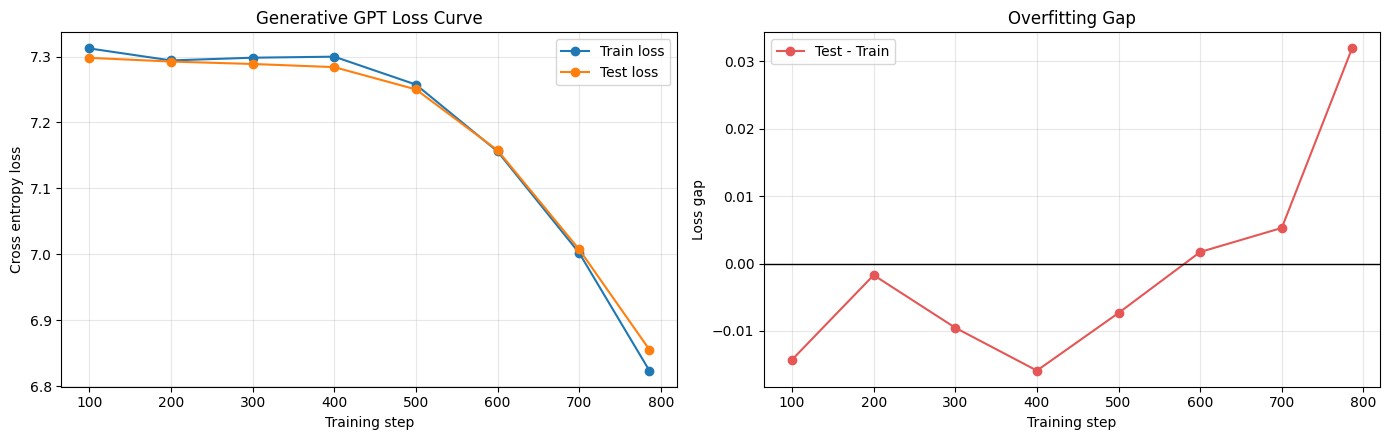

REPORT.md 기록용
- model params: 2,957,112
- final train loss: 6.8236
- final test loss: 6.8555
- final gap(test-train): 0.0319
- tokens seen: 804,864
- elapsed: 53.9초
- checkpoint: /Users/magik/Documents/jungle/02gpt-lab/checkpoints/report_basic_last.pt

생성 샘플
[이 영화는] 이 영화는이 나이와 이가. 영화고 지 한편없다 이런. 재밌네요의 왜, 하이 남한 전인도 그. 대가있게,. 영화, 그리고 하은 다의 기가 재밌인할�
[배우들의 연기는] 배우들의 연기는아! ㅎ가 보는데 2의 사랑화의 무상과 비우작 스토리는 자의 사랑으로 무리수, 너무 좋음 g, 사랑은 보러이 이 영화, 재밌음이 역시 그
[스토리는] 스토리는 가한 왜가 이하아...정말.. 그다. 무지지... 말을 본하라이 하지..나도 어도 한음, 나의 �다. 그 너무 더 좋고 안하고 고�게 정말 감동한 그


In [9]:
# matplotlib 기반 train loss / test loss 과대적합 확인 시각화
import matplotlib.pyplot as plt

if "report_pretrain_history" not in globals() or not report_pretrain_history:
    raise RuntimeError("먼저 생성형 GPT 사전학습 실행 셀을 완료하세요.")

steps = [row["step"] for row in report_pretrain_history]
train_losses = [row["train_loss"] for row in report_pretrain_history]
test_losses = [row["test_loss"] for row in report_pretrain_history]
gaps = [test - train for train, test in zip(train_losses, test_losses)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(steps, train_losses, marker="o", label="Train loss")
axes[0].plot(steps, test_losses, marker="o", label="Test loss")
axes[0].set_title("Generative GPT Loss Curve")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Cross entropy loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(steps, gaps, marker="o", color="#E45756", label="Test - Train")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Overfitting Gap")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Loss gap")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

final_row = report_pretrain_history[-1]
print("REPORT.md 기록용")
print("- model params:", f"{report_model_param_count:,}")
print("- final train loss:", f"{final_row['train_loss']:.4f}")
print("- final test loss:", f"{final_row['test_loss']:.4f}")
print("- final gap(test-train):", f"{final_row['test_loss'] - final_row['train_loss']:.4f}")
print("- tokens seen:", f"{final_row['tokens_seen']:,}")
print("- elapsed:", fmt_seconds(report_pretrain_elapsed))
print("- checkpoint:", REPORT_PATHS["checkpoint"])

print("\n생성 샘플")
for sample in report_pretrain_samples:
    print(f"[{sample['prompt']}] {compact_text(sample['text'], max_len=300)}")


## 11. 하이퍼파라미터 탐색

`scripts/run_hparam_search.py`는 전체 648개 조합 중 seed=42로 선택한 64개 Medium 예산 조합을 자동 실행합니다. 결과는 checkpoint 없이 `results/hparam_search/runs.jsonl`과 `results/hparam_search/summary.csv`에 저장합니다.

In [ ]:
!python scripts/run_hparam_search.py --budget medium

In [ ]:
# 하이퍼파라미터 탐색 결과 요약
import csv

summary_path = repo_dir / "results" / "hparam_search" / "summary.csv"
if not summary_path.exists():
    raise FileNotFoundError(f"아직 탐색 결과가 없습니다: {summary_path}")

with summary_path.open("r", encoding="utf-8", newline="") as f:
    rows = list(csv.DictReader(f))

if not rows:
    raise RuntimeError("완료된 하이퍼파라미터 탐색 결과가 없습니다.")

top_rows = rows[:10]
columns = [
    "rank",
    "best_val_loss",
    "final_train_loss",
    "batch_size",
    "drop_rate",
    "learning_rate",
    "context_length",
    "n_layers",
    "emb_dim",
    "elapsed_seconds",
]
markdown_lines = ["| " + " | ".join(columns) + " |", "| " + " | ".join(["---"] * len(columns)) + " |"]
for rank, row in enumerate(top_rows, start=1):
    values = [str(rank)] + [row.get(column, "") for column in columns[1:]]
    markdown_lines.append("| " + " | ".join(values) + " |")

try:
    from IPython.display import Markdown, display
    display(Markdown("\n".join(markdown_lines)))
except ImportError:
    print("\n".join(markdown_lines))

best = rows[0]
print("best run:", best["run_id"])
print("best val loss:", best["best_val_loss"])
print("hyperparams:", {key: best[key] for key in ["batch_size", "drop_rate", "learning_rate", "context_length", "n_layers", "emb_dim"]})
print("sample:", best.get("generated_sample", "")[:300])

## 12. [삼각 관계] 연구 실험

이 섹션은 기존 attention을 비교 기준으로 두고 [삼각 관계] 자동 연구 루프를 실행합니다. 결과는 `reports/triangular_relation_research.md`에 누적됩니다.

- `standard`: 기존 pairwise attention
- `triangular_v0`: 현재 baseline, score는 `(i,j,k)`, value는 marginal 평균
- `triangular_v1_pair_value`: pair interaction value + marginal residual
- `triangular_v2_scaled`: v1 + learned logit scale + entropy logging
- `triangular_v3_topk`: v2 + top-k candidate pair selection
- `triangular_v4_gated_pair`: learned gate로 pair-value 경로를 점진적으로 반영
- `triangular_v5_gated_topk`: gated pair-value + top-k, 현재 첫 만족 후보

자동 루프는 먼저 synthetic `give(subject, object, recipient)` task에서 세 토큰 조합 인식 능력을 확인하고, 표준 attention 이상인 [삼각 관계] 후보를 NSMC LM 비교로 넘깁니다. 기본 학습량은 1000 step 이상이며, 첫 만족 후보는 `facts=4`, `answer_relation`, `top_k=8`, `steps=2000` 조건에서 나왔습니다.


In [ ]:
# 자동 연구 루프: synthetic screening -> NSMC validation
import subprocess
import sys
from pathlib import Path

RESEARCH_MD = REPO_ROOT / "reports" / "triangular_relation_research.md"
RUN_ID = "notebook_auto_triangular_v5_2000"
AUTO_DIR = REPO_ROOT / "reports" / "auto_triangular_research" / RUN_ID / "iter_01"
SYN_JSON = AUTO_DIR / "synthetic.json"
SYN_PLOT = AUTO_DIR / "synthetic_accuracy.png"
LM_JSON = AUTO_DIR / "nsmc.json"
LM_PLOT = AUTO_DIR / "nsmc_loss.png"

cmd = [
    sys.executable, "scripts/auto_triangular_research.py",
    "--run-id", RUN_ID,
    "--iterations", "1",
    "--steps", "2000",
    "--eval-every", "100",
    "--variants", "standard,triangular_v5_gated_topk",
    "--seeds", "123",
    "--synthetic-facts", "4",
    "--synthetic-loss-mode", "answer_relation",
    "--synthetic-relation-loss-weight", "0.5",
    "--synthetic-batch-size", "32",
    "--synthetic-eval-batches", "20",
    "--top-k", "8",
    "--nsmc-context-length", "32",
    "--nsmc-batch-size", "8",
    "--nsmc-eval-batches", "8",
    "--max-selected-variants", "2",
    "--report-md", str(RESEARCH_MD),
]

print("실행 명령:", " ".join(cmd))
result = subprocess.run(cmd, cwd=REPO_ROOT)
if result.returncode != 0:
    raise RuntimeError(f"[삼각 관계] 자동 연구 루프 실패: exit code {result.returncode}")


In [ ]:
# 자동 루프가 생성한 산출물 위치 확인
for path in [SYN_JSON, SYN_PLOT, LM_JSON, LM_PLOT, RESEARCH_MD]:
    print(path, "exists=", path.exists())


In [ ]:
# 결과 요약과 누적 보고서 확인
import json
from IPython.display import Image, Markdown, display

def show_result(path, metric_name):
    data = json.loads(path.read_text(encoding="utf-8"))
    print("\n==", path.name, "==")
    for r in data["results"]:
        if metric_name == "accuracy":
            print(f"{r['variant']:<26} acc={r['final_accuracy']:.3f} best={r['best_accuracy']:.3f} ms={r['ms_per_step']:.2f}")
        else:
            print(f"{r['variant']:<26} val={r['final_val_loss']:.4f} best={r['best_val_loss']:.4f} ms={r['ms_per_step']:.2f}")

show_result(SYN_JSON, "accuracy")
show_result(LM_JSON, "loss")

display(Image(filename=str(SYN_PLOT)))
display(Image(filename=str(LM_PLOT)))
display(Markdown(RESEARCH_MD.read_text(encoding="utf-8")[-5000:]))


## 13. 생성형 모델 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 생성형 모델 관련 테스트를 한 번 더 확인합니다.

In [ ]:
for test_file in [
    "tests/test_bpe.py",
    "tests/test_dataset.py",
    "tests/test_attention.py",
    "tests/test_model.py",
    "tests/test_train.py",
]:
    result = run_pytest(test_file)
    if result != 0:
        break